In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_datasets as tfds
# tfds.disable_progress_bar()

from tensorflow import keras

In [2]:
tfds.list_builders()

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkeley_mvp_converted_externally_to_rlds',
 'berkeley_rpt_converted_externally_to_rlds',
 'big_patent',
 'bigearthnet',
 'billsum',
 '

## Get information on the data

In [3]:
builder = tfds.builder('rock_paper_scissors')

In [4]:
info = builder.info

In [5]:
info

tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='C:\\Users\\newta\\tensorflow_datasets\\rock_paper_scissors\\3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moroney",
    title = "Rock, Paper, Scissors Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemo

## Prepare rock paper scissors data


In [6]:
ds_train = tfds.load(name = 'rock_paper_scissors', split = "train")

In [7]:
ds_test = tfds.load(name = "rock_paper_scissors", split = "test")

## Show examples

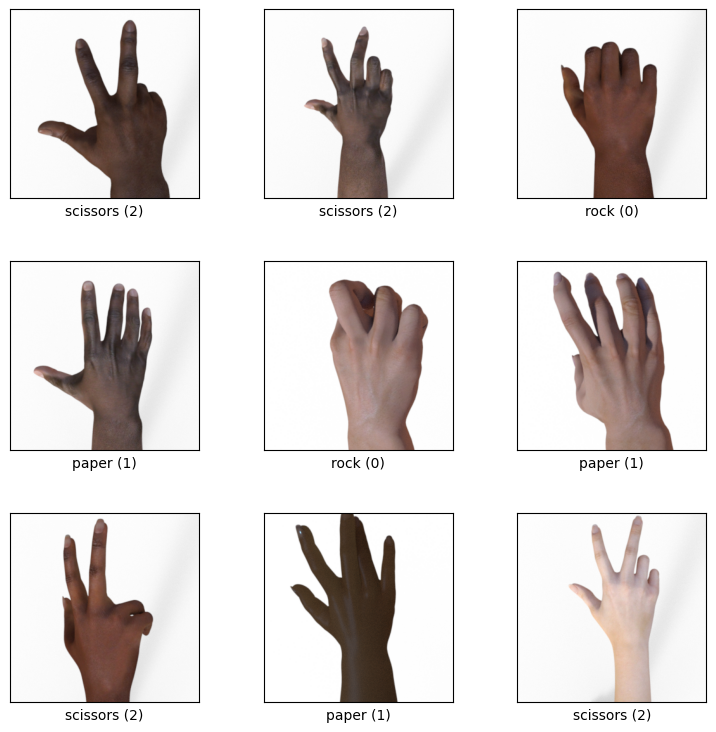

In [8]:
fig = tfds.show_examples(ds_train, info )

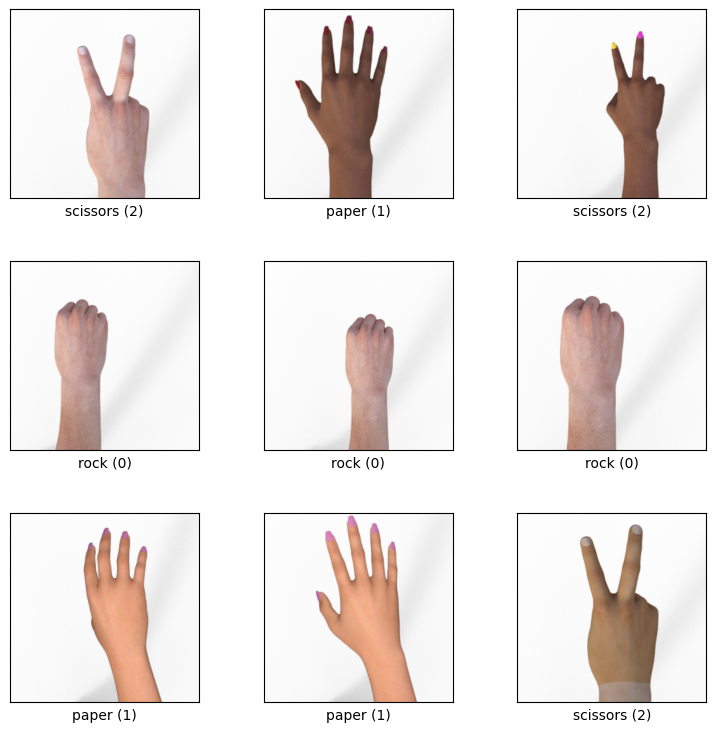

Figure(900x900)


In [9]:
fig = tfds.show_examples(ds_test, info )
print(fig)

## Additional data prep

In [10]:
train_images = np.array([example['image'] for example in ds_train])

In [11]:
train_images[0]

array([[[254, 254, 254],
        [253, 253, 253],
        [254, 254, 254],
        ...,
        [251, 251, 251],
        [250, 250, 250],
        [250, 250, 250]],

       [[254, 254, 254],
        [254, 254, 254],
        [253, 253, 253],
        ...,
        [250, 250, 250],
        [251, 251, 251],
        [249, 249, 249]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [251, 251, 251],
        [250, 250, 250],
        [252, 252, 252]],

       ...,

       [[252, 252, 252],
        [251, 251, 251],
        [252, 252, 252],
        ...,
        [247, 247, 247],
        [249, 249, 249],
        [248, 248, 248]],

       [[253, 253, 253],
        [253, 253, 253],
        [251, 251, 251],
        ...,
        [248, 248, 248],
        [248, 248, 248],
        [248, 248, 248]],

       [[252, 252, 252],
        [253, 253, 253],
        [252, 252, 252],
        ...,
        [248, 248, 248],
        [247, 247, 247],
        [250, 250, 250]]

In [12]:
train_images = np.array([example['image'].numpy()[:,:,0] for example in ds_train])
train_labels = np.array([example['label'].numpy() for example in ds_train] )

test_images = np.array([example['image'].numpy()[:,:,0] for example in ds_test])
test_labels = np.array([example['label'].numpy() for example in ds_test] )

In [13]:
train_images[0]

array([[254, 253, 254, ..., 251, 250, 250],
       [254, 254, 253, ..., 250, 251, 249],
       [254, 254, 254, ..., 251, 250, 252],
       ...,
       [252, 251, 252, ..., 247, 249, 248],
       [253, 253, 251, ..., 248, 248, 248],
       [252, 253, 252, ..., 248, 247, 250]], shape=(300, 300), dtype=uint8)

In [14]:
train_images.shape

(2520, 300, 300)

In [15]:
test_images.shape

(372, 300, 300)

#### Need to turn it to one dimension in end too, so that because convolution networks expect at least one color (RGB)

In [16]:
train_images = train_images.reshape(2520, 300, 300, 1)

In [17]:
test_images = test_images.reshape(372, 300, 300, 1)

In [18]:
train_images.dtype

dtype('uint8')

In [19]:
train_images = train_images.astype('float')
test_images = test_images.astype('float')

In [20]:
train_images

array([[[[254.],
         [253.],
         [254.],
         ...,
         [251.],
         [250.],
         [250.]],

        [[254.],
         [254.],
         [253.],
         ...,
         [250.],
         [251.],
         [249.]],

        [[254.],
         [254.],
         [254.],
         ...,
         [251.],
         [250.],
         [252.]],

        ...,

        [[252.],
         [251.],
         [252.],
         ...,
         [247.],
         [249.],
         [248.]],

        [[253.],
         [253.],
         [251.],
         ...,
         [248.],
         [248.],
         [248.]],

        [[252.],
         [253.],
         [252.],
         ...,
         [248.],
         [247.],
         [250.]]],


       [[[254.],
         [253.],
         [254.],
         ...,
         [252.],
         [250.],
         [250.]],

        [[253.],
         [255.],
         [253.],
         ...,
         [251.],
         [251.],
         [250.]],

        [[254.],
         [253.],
      

In [21]:
train_labels.shape

(2520,)

In [22]:
train_images = train_images/255
test_images = test_images/255

In [23]:
train_images

array([[[[0.99607843],
         [0.99215686],
         [0.99607843],
         ...,
         [0.98431373],
         [0.98039216],
         [0.98039216]],

        [[0.99607843],
         [0.99607843],
         [0.99215686],
         ...,
         [0.98039216],
         [0.98431373],
         [0.97647059]],

        [[0.99607843],
         [0.99607843],
         [0.99607843],
         ...,
         [0.98431373],
         [0.98039216],
         [0.98823529]],

        ...,

        [[0.98823529],
         [0.98431373],
         [0.98823529],
         ...,
         [0.96862745],
         [0.97647059],
         [0.97254902]],

        [[0.99215686],
         [0.99215686],
         [0.98431373],
         ...,
         [0.97254902],
         [0.97254902],
         [0.97254902]],

        [[0.98823529],
         [0.99215686],
         [0.98823529],
         ...,
         [0.97254902],
         [0.96862745],
         [0.98039216]]],


       [[[0.99607843],
         [0.99215686],
         [0.99

# Train a network for this task

In [24]:
model = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer = 'adam',
              loss = keras.losses.SparseCategoricalCrossentropy(),
             metrics = ['accuracy'])


model.fit(train_images, train_labels, epochs = 6, batch_size = 32)

Epoch 1/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.3992 - loss: 24.1733
Epoch 2/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 352ms/step - accuracy: 0.6198 - loss: 5.2819
Epoch 3/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 359ms/step - accuracy: 0.7829 - loss: 0.7917
Epoch 4/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 342ms/step - accuracy: 0.7643 - loss: 0.8651
Epoch 5/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 336ms/step - accuracy: 0.7885 - loss: 0.7688
Epoch 6/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 346ms/step - accuracy: 0.8171 - loss: 0.6860


In [25]:
model.evaluate(test_images, test_labels)[1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4731 - loss: 3.0890


0.47311827540397644

# Convolutional Networks

In [26]:
model = keras.Sequential([

    keras.layers.Conv2D(64, 3, activation='relu', input_shape = (300, 300, 1)),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(3, activation = 'softmax')   
]
)


model.compile(optimizer = 'adam',
              loss = keras.losses.SparseCategoricalCrossentropy(),
             metrics = ['accuracy'])


model.fit(train_images, train_labels, epochs = 6, batch_size = 32)

C:\Users\newta\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.7139 - loss: 1.8990
Epoch 2/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step - accuracy: 0.9726 - loss: 0.1588
Epoch 3/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 283s 4s/step - accuracy: 0.9940 - loss: 0.0250
Epoch 4/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy: 0.9988 - loss: 0.0076
Epoch 5/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 290s 4s/step - accuracy: 0.9996 - loss: 0.0024
Epoch 6/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 1.0000 - loss: 0.0012


In [28]:
model.evaluate(test_images, test_labels)[1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 830ms/step - accuracy: 0.5887 - loss: 1.2347


0.5887096524238586

## A better convolutional network

### Average Pooling

🔍 What it does (intuitively)

Your layer:

keras.layers.AveragePooling2D(6, 3)

means:

Take a 6×6 window
Move it across the image with a stride of 3
Replace each window with the average of its values

So instead of keeping all pixel details, it summarizes regions.

🧠 Why we use Average Pooling

Even if you added it because your model wasn’t performing well, there are solid reasons it can help:

1. Reduces dimensionality
Your input is 300×300, which is large.
Pooling shrinks it → fewer computations → faster training.
2. Prevents overfitting
By compressing information, it removes noise and small variations.
This helps the model generalize better instead of memorizing details.
3. Captures general patterns
Instead of focusing on exact pixel values, it keeps the overall structure.
Useful when exact position/details don’t matter too much.
4. Stabilizes features
Averaging smooths out activations → less sensitivity to small changes.
🤔 Why it might have improved your model

Before pooling:

Too many pixels → too many parameters → model struggles or overfits

After pooling:

Smaller, cleaner feature maps → easier for Conv layers to learn meaningful patterns
⚖️ Average Pooling vs Max Pooling
Average Pooling → smooths (keeps overall info)
Max Pooling → keeps strongest feature (edges, textures)

Most modern CNNs actually prefer MaxPooling, but AveragePooling can still help when:

You want smoother representations
Data is noisy
You care about overall intensity rather than sharp features
🚀 Simple analogy

Imagine looking at a photo:

Without pooling → you examine every pixel
With average pooling → you blur small regions and focus on the bigger picture

In [29]:
model = keras.Sequential([
    keras.layers.AveragePooling2D(6,3, input_shape = (300, 300, 1)),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(3, activation = 'softmax')   
]
)


model.compile(optimizer = 'adam',
              loss = keras.losses.SparseCategoricalCrossentropy(),
             metrics = ['accuracy'])


model.fit(train_images, train_labels, epochs = 6, batch_size = 32)

C:\Users\newta\anaconda3\Lib\site-packages\keras\src\layers\pooling\base_pooling.py:23: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(name=name, **kwargs)


Epoch 1/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 406ms/step - accuracy: 0.6012 - loss: 1.1672
Epoch 2/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - accuracy: 0.9341 - loss: 0.2747
Epoch 3/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 361ms/step - accuracy: 0.9869 - loss: 0.0792
Epoch 4/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 371ms/step - accuracy: 0.9956 - loss: 0.0295
Epoch 5/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 376ms/step - accuracy: 0.9988 - loss: 0.0126
Epoch 6/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 371ms/step - accuracy: 0.9996 - loss: 0.0063


In [30]:
model.evaluate(test_images, test_labels)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.6586 - loss: 1.0120


[1.0119867324829102, 0.6586021780967712]

MODEL EXPLANATION (Layer by Layer)

Input shape: (300, 300, 1) → grayscale image

---

1. AveragePooling2D(6, 3)

What it does:

* Takes a 6×6 region of the image
* Moves with stride 3
* Replaces each region with its average value

Effect:

* Reduces image size (downsampling)
* Removes noise and small details
* Keeps general structure

Why used:

* Makes computation faster
* Helps prevent overfitting
* Reduces input size before convolution

---

2. Conv2D(64, 3, activation='relu')

What it does:

* Applies 64 different 3×3 filters
* Each filter scans the image and detects patterns

Output:

* Produces 64 feature maps

What it learns:

* Edges
* Lines
* Basic textures

ReLU activation:

* Converts negative values to 0
* Keeps positive values unchanged

Why ReLU:

* Adds non-linearity
* Helps model learn complex patterns
* Prevents vanishing gradient problem

---

3. Conv2D(32, 3, activation='relu')

What it does:

* Applies 32 filters on previous feature maps

Effect:

* Learns more complex patterns (combinations of earlier features)

Why fewer filters (32 vs 64):

* Reduces complexity
* Forces model to compress useful information

---

4. MaxPool2D(2, 2)

What it does:

* Takes a 2×2 region
* Keeps ONLY the maximum value

Effect:

* Reduces spatial size
* Keeps strongest features (like edges)

Why used:

* Makes model efficient
* Keeps important signals
* Reduces overfitting

---

5. Dropout(0.5)

What it does:

* Randomly turns off 50% of neurons during training

Effect:

* Prevents model from depending too much on specific neurons

Why used:

* Reduces overfitting
* Improves generalization

Important:

* Only active during training, not during testing

---

6. Flatten()

What it does:

* Converts multi-dimensional data → 1D vector

Example:

* From (height, width, channels)
* To (single long vector)

YES:

* It converts data into a 1D column/vector

Why needed:

* Dense layers require 1D input

---

7. Dense(128, activation='relu')

What it does:

* Fully connected layer with 128 neurons

Effect:

* Combines all extracted features
* Learns complex relationships

ReLU used here:

* Helps learn non-linear combinations of features

---

8. Dense(3, activation='softmax')

What it does:

* Final output layer with 3 neurons (for 3 classes)

Softmax:

* Converts outputs into probabilities
* All outputs sum to 1

Example:
[0.1, 0.7, 0.2] → class 2 is predicted

---

ACTIVATION FUNCTIONS

ReLU (Rectified Linear Unit):

* Formula: max(0, x)
* Used in:

  * Hidden layers (Conv, Dense)
* Why:

  * Fast
  * Avoids vanishing gradient
  * Works well in deep networks

---

Sigmoid:

* Output range: 0 to 1
* Formula: 1 / (1 + e^-x)

Used in:

* Binary classification (1 output neuron)

Problem:

* Can cause vanishing gradients
* Not used in deep hidden layers

---

Softmax:

* Used in multi-class classification
* Converts outputs into probabilities

Used in:

* Final layer when classes > 2

---

SUMMARY FLOW

Image (300×300)
→ AveragePooling (downsample)
→ Conv2D (feature extraction)
→ Conv2D (deeper features)
→ MaxPooling (reduce size)
→ Dropout (regularization)
→ Flatten (convert to 1D)
→ Dense (learn patterns)
→ Dense (final prediction)

---

KEY IDEA

* Conv layers → extract features
* Pooling → reduce size
* Dropout → prevent overfitting
* Flatten → prepare for Dense
* Dense → classification


In [31]:
# Max pooling

model = keras.Sequential([
    keras.layers.AveragePooling2D(6,3, input_shape = (300, 300, 1)),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.MaxPool2D(2,2),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dense(3, activation = 'softmax')   
]
)


model.compile(optimizer = 'adam',
              loss = keras.losses.SparseCategoricalCrossentropy(),
             metrics = ['accuracy'])


model.fit(train_images, train_labels, epochs = 6, batch_size = 32)

Epoch 1/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 396ms/step - accuracy: 0.7655 - loss: 0.6583
Epoch 2/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 414ms/step - accuracy: 0.9833 - loss: 0.0844
Epoch 3/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 399ms/step - accuracy: 0.9960 - loss: 0.0199
Epoch 4/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 404ms/step - accuracy: 1.0000 - loss: 0.0070
Epoch 5/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 400ms/step - accuracy: 1.0000 - loss: 0.0032
Epoch 6/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 413ms/step - accuracy: 1.0000 - loss: 0.0020


In [32]:
model.evaluate(test_images, test_labels)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.7070 - loss: 1.0637


[1.0636540651321411, 0.7069892287254333]

# Hyperparamater tuning

### Keras Tuner is used for automatically finding the best hyperparameters for your model.
### Number of filters, learning rate, batch size, number of layers, dropout rate

In [39]:
from kerastuner.tuners import RandomSearch

def build_model(hp):
  model = keras.Sequential()

  model.add(keras.layers.AveragePooling2D(6,3,input_shape=(300,300,1)))

  for i in range(hp.Int("Conv Layers", min_value=0, max_value=3)):
    model.add(keras.layers.Conv2D(hp.Choice(f"layer_{i}_filters", [16,32,64]), 3, activation='relu'))
  
  model.add(keras.layers.MaxPool2D(2,2))
  model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Flatten())

  model.add(keras.layers.Dense(hp.Choice("Dense layer", [64, 128, 256, 512, 1024]), activation='relu'))

  model.add(keras.layers.Dense(3, activation='softmax'))

  model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
  
  return model


tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=32,
)




Reloading Tuner from .\untitled_project\tuner0.json


In [40]:
tuner.search(train_images, train_labels, validation_data=(test_images, test_labels), epochs=5, batch_size=64)

Trial 32 Complete [00h 03m 18s]
val_accuracy: 0.7419354915618896

Best val_accuracy So Far: 0.8037634491920471
Total elapsed time: 01h 28m 35s


In [42]:
best_model = tuner.get_best_models()[0]

In [43]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ average_pooling2d (AveragePooling2D) │ (None, 99, 99, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 97, 97, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 147456)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      18,874,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,875,523 (72.00 MB)

 Trainable params: 18,875,523 (72.00 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
best_model.evaluate(test_images, test_labels)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8038 - loss: 0.7432


[0.7432109713554382, 0.8037634491920471]

In [46]:
tuner.results_summary()

Results summary
Results in .\untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 21 summary
Hyperparameters:
Conv Layers: 1
Dense layer: 128
layer_0_filters: 64
layer_1_filters: 16
layer_2_filters: 64
Score: 0.8037634491920471

Trial 13 summary
Hyperparameters:
Conv Layers: 1
Dense layer: 128
layer_0_filters: 64
layer_1_filters: 32
layer_2_filters: 32
Score: 0.7795698642730713

Trial 07 summary
Hyperparameters:
Conv Layers: 3
Dense layer: 1024
layer_0_filters: 64
layer_1_filters: 16
layer_2_filters: 16
Score: 0.774193525314331

Trial 04 summary
Hyperparameters:
Conv Layers: 2
Dense layer: 256
layer_0_filters: 16
layer_1_filters: 64
layer_2_filters: 64
Score: 0.7607526779174805

Trial 26 summary
Hyperparameters:
Conv Layers: 3
Dense layer: 64
layer_0_filters: 32
layer_1_filters: 32
layer_2_filters: 16
Score: 0.7553763389587402

Trial 05 summary
Hyperparameters:
Conv Layers: 1
Dense layer: 1024
layer_0_filters: 64
layer_1_filters: 32
layer_2_fil

# Save & Load our Models

In [48]:
best_model.save('./my_model.keras')

In [49]:
loaded_model = keras.models.load_model('./my_model.keras')

C:\Users\newta\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [50]:
loaded_model.evaluate(test_images, test_labels)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8038 - loss: 0.7432


[0.7432109713554382, 0.8037634491920471]

# Plot Image from Numpy Array

In [51]:
ds_train

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>

In [57]:
type(ds_train)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [58]:
type(ds_train.take(1))

tensorflow.python.data.ops.take_op._TakeDataset

.take(1) is a method from TensorFlow datasets (tf.data.Dataset).

What it does:

.take(1) returns a new dataset containing only the first 1 element from ds_train


creates an iterable dataset with just the first batch (or first element)
The list comprehension loops over that single element

In [60]:
image = train_images[0].reshape(300, 300)

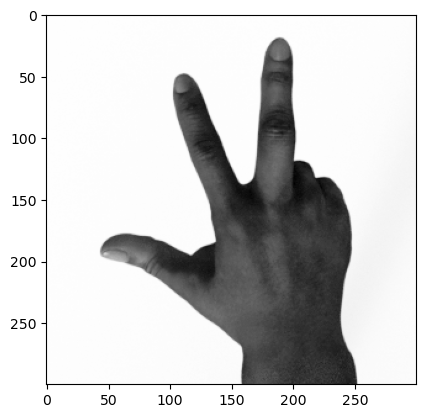

In [61]:
plt.imshow(image, cmap = 'Greys_r')

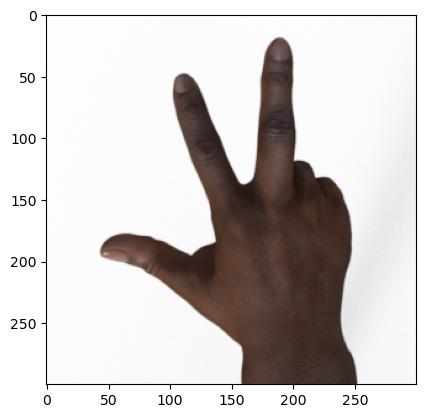

In [63]:
rgb_images = np.array([example['image'].numpy() for example in ds_train.take(1)])
rgb_image = rgb_images[0]

plt.imshow(rgb_image)

In [64]:
rgb_image.shape

(300, 300, 3)

In [65]:
image.shape

(300, 300)

# Use Model to Predict Result for Single Example

In [66]:
result = best_model.predict(np.array([train_images[0]]))
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
[[0.01128194 0.01725541 0.9714626 ]]


In [67]:
predicted_value = np.argmax(result)
print(predicted_value)

2


# Convert PNG/JPG images to Numpy Format

In [68]:
import imageio

im = imageio.imread('https://upload.wikimedia.org/wikipedia/commons/thumb/8/84/Massachusetts_State_House_-_panoramio_%281%29.jpg/280px-Massachusetts_State_House_-_panoramio_%281%29.jpg')

print(type(im))

im_np = np.asarray(im)

print(im_np.shape)

C:\Users\newta\AppData\Local\Temp\ipykernel_16948\2086929921.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('https://upload.wikimedia.org/wikipedia/commons/thumb/8/84/Massachusetts_State_House_-_panoramio_%281%29.jpg/280px-Massachusetts_State_House_-_panoramio_%281%29.jpg')


HTTPError: HTTP Error 403: Forbidden